In [1]:
import gayum
import numpy as np
import pandas as pd
import plotnine as p9
from plotnine.data import mtcars

In [2]:
f = gayum.Formula(
    response="mpg",
    terms=[gayum.terms.s("hp"), gayum.terms.s("wt"), gayum.terms.s("disp")],
    df=mtcars
)
model = gayum.GAM(formula=f)

X = mtcars[["hp", "wt", "disp"]]
y = mtcars[["mpg"]]
model = model.fit(X, y)

pred_df = mtcars[["hp", "wt", "disp", "mpg"]]
pred_df["pred"] = np.asarray(model.predict(pred_df[["hp", "wt", "disp"]]))

pred_df["wt_bin"] = pd.qcut(pred_df["wt"], q=3, labels=["light", "mid", "heavy"])

hp_grid = np.linspace(pred_df["hp"].min(), pred_df["hp"].max(), 120)
levels = (
    pred_df.groupby("wt_bin", observed=False)[["wt", "disp"]]
    .median()
    .reset_index()
)

grid = (
    levels.assign(_k=1)
    .merge(pd.DataFrame({"hp": hp_grid, "_k": 1}), on="_k")
    .drop(columns="_k")
)

grid["pred"] = np.asarray(model.predict(grid[["hp", "wt", "disp"]]))
pred_df['resid'] = pred_df['mpg'] - pred_df['pred']
rmse = np.sqrt(np.mean((pred_df['resid']) ** 2))

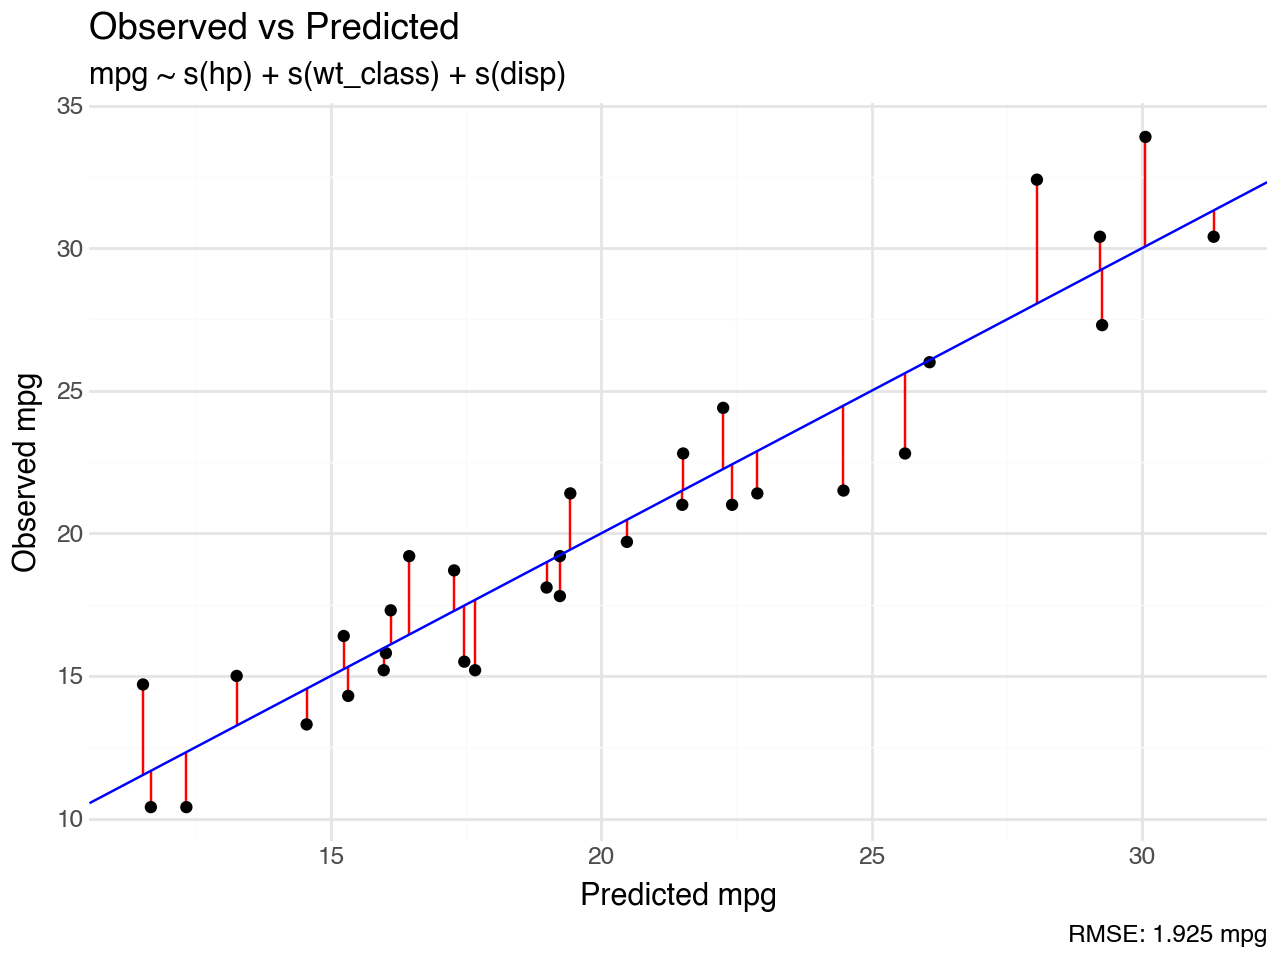

In [3]:
(
    p9.ggplot(pred_df, p9.aes(x='pred', y='mpg'))
    + p9.geom_segment(mapping=p9.aes(x='pred', y='pred', xend='pred', yend='mpg'), color='red')
    + p9.geom_point()
    + p9.geom_abline(intercept=0, slope=1, color='blue')
    + p9.theme_minimal()
    + p9.labs(
        title='Observed vs Predicted',
        subtitle='mpg ~ s(hp) + s(wt_class) + s(disp)',
        caption=f'RMSE: {rmse:.3f} mpg',
        x='Predicted mpg',
        y='Observed mpg'
    )
).show()